<a href="https://colab.research.google.com/github/PaperCodeGithub/audio-emotion-recognition/blob/main/audio_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install resampy

In [ ]:
import tensorflow as tf
tf.test.gpu_device_name()


'/device:GPU:0'

In [ ]:
import numpy as np
import tensorflow as tf
import os
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping


In [ ]:
EMOTIONS_DICT = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
DATASET_PATH = "/kaggle/input/ravdess-emotional-speech-audio/"

def get_mfcc_from_audio(audio, sample_rate, max_pad_len=100):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

    if mfccs.shape[1] > max_pad_len:
        mfccs = mfccs[:, :max_pad_len]
    else:
        pad_width = max_pad_len - mfccs.shape[1]
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    return mfccs

def extract_augmented_features(file_path):
    features_list = []

    try:
        audio, sample_rate = librosa.load(file_path)
        clean_mfcc = get_mfcc_from_audio(audio, sample_rate)
        features_list.append(clean_mfcc)

        noise_amp = 0.005 * np.random.uniform() * np.amax(audio)
        noisy_audio = audio + noise_amp * np.random.normal(size=audio.shape[0])
        noisy_mfcc = get_mfcc_from_audio(noisy_audio, sample_rate)
        features_list.append(noisy_mfcc)

        step = np.random.choice([-2, -1, 1, 2])
        pitched_audio = librosa.effects.pitch_shift(y=audio, sr=sample_rate, n_steps=step)
        pitched_mfcc = get_mfcc_from_audio(pitched_audio, sample_rate)
        features_list.append(pitched_mfcc)

        return features_list

    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

def extract_file_label():
    X = []
    y = []

    for actor_dir in os.listdir(DATASET_PATH):
        actor_path = os.path.join(DATASET_PATH, actor_dir)

        if not os.path.isdir(actor_path):
            continue

        for file_name in os.listdir(actor_path):
            if file_name.endswith('.wav'):
                file_path = os.path.join(actor_path, file_name)
                file_parts = file_name.split('-')
                emotion_code = file_parts[2]

                emotion_label = EMOTIONS_DICT[emotion_code]
                features = extract_augmented_features(file_path)

                if features is not None:
                    for f in features:
                        X.append(f)
                        y.append(emotion_label)
                        print(f"Appended {emotion_label}")

    return np.array(X), np.array(y)

In [ ]:
X, Y = extract_file_label()

print("Data Extraction Complete")

if X.size == 0:
    print("Error: No data was extracted. This is likely due to the 'No module named resampy' error reported earlier.")
    print("Please ensure 'resampy' is correctly installed and accessible by librosa. Restarting the Colab runtime and re-running all cells might resolve this issue.")
else:
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    label_encoder = LabelEncoder()
    y_integers = label_encoder.fit_transform(Y)
    Y = to_categorical(y_integers)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    num_emotions = Y.shape[1]

    print("Data Processing Complete")

Appended surprised
Appended surprised
Appended surprised
Appended neutral
Appended neutral
Appended neutral
Appended disgust
Appended disgust
Appended disgust
Appended disgust
Appended disgust
Appended disgust
Appended neutral
Appended neutral
Appended neutral
Appended fearful
Appended fearful
Appended fearful
Appended sad
Appended sad
Appended sad
Appended neutral
Appended neutral
Appended neutral
Appended calm
Appended calm
Appended calm
Appended happy
Appended happy
Appended happy
Appended disgust
Appended disgust
Appended disgust
Appended angry
Appended angry
Appended angry
Appended happy
Appended happy
Appended happy
Appended fearful
Appended fearful
Appended fearful
Appended surprised
Appended surprised
Appended surprised
Appended fearful
Appended fearful
Appended fearful
Appended fearful
Appended fearful
Appended fearful
Appended calm
Appended calm
Appended calm
Appended sad
Appended sad
Appended sad
Appended happy
Appended happy
Appended happy
Appended disgust
Appended disgust


In [ ]:
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(40, 100, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),
    Dropout(0.2),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),
    Dropout(0.3),

    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_emotions, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

print("Model Generated")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 23, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 21, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 10, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,355,656 (5.17 MB)

 Trainable params: 1,354,760 (5.17 MB)

 Non-trainable params: 896 (3.50 KB)

Model Generated


Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.2072 - loss: 2.0872 - val_accuracy: 0.2616 - val_loss: 1.9952
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2674 - loss: 1.8400 - val_accuracy: 0.3519 - val_loss: 1.6997
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3032 - loss: 1.7561 - val_accuracy: 0.3727 - val_loss: 1.6596
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3131 - loss: 1.7057 - val_accuracy: 0.4178 - val_loss: 1.5352
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3458 - loss: 1.6295 - val_accuracy: 0.4225 - val_loss: 1.5361
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3721 - loss: 1.5636 - val_accuracy: 0.4606 - val_loss: 1.4309
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3955 - loss: 1.4895 - val_accuracy: 0.5069 - val_loss: 1.3119
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4219 - loss: 1.4274 - val_acc

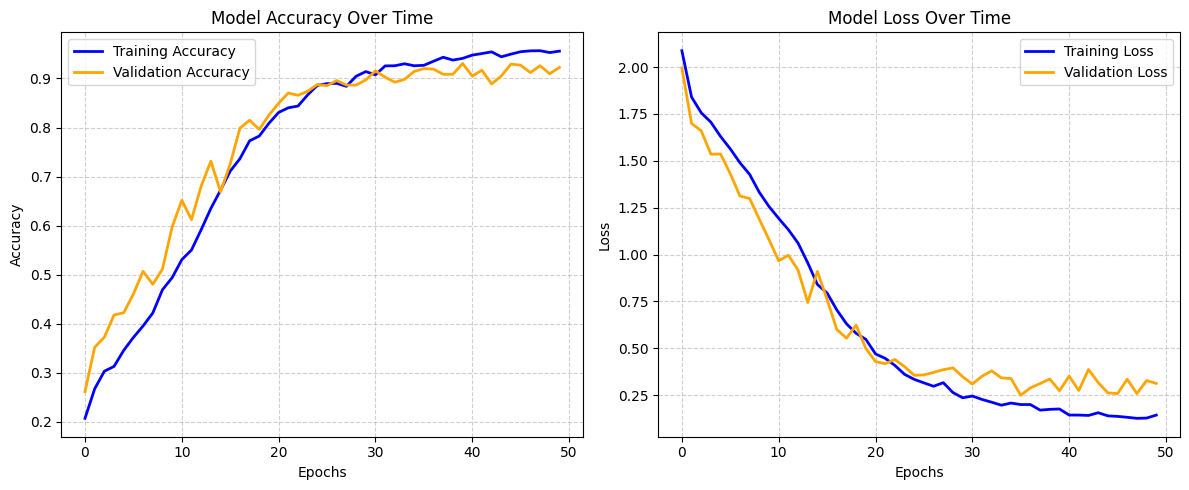

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test)
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()